## TOTAL STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

total=pd.read_csv('../stock_data/total.csv') ## so it can be small letter. This is cool.
total=total.drop(columns=['high_price','low_price'])
total.rename(columns={'trade_date':'date'},inplace=True)
total['date']=pd.to_datetime(total['date'])
total['month']=total['date'].dt.month
total['quarter']=total['date'].dt.quarter
total['year']=total['date'].dt.year

total

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42853,TOTAL,2017-01-03,299.0,299.0,8617,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43413,TOTAL,2017-01-04,299.0,299.0,7647,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43523,TOTAL,2017-01-05,299.0,299.0,4834,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43633,TOTAL,2017-01-06,299.0,299.0,11103,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43723,TOTAL,2017-01-09,300.0,300.0,128985,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298138,TOTAL,2026-07-13,640.0,640.0,5309,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298576,TOTAL,2026-07-14,640.0,640.0,1815,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299014,TOTAL,2026-07-15,640.0,640.0,2045,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299452,TOTAL,2026-07-16,640.0,640.0,2106,2026-07-16T15:10:03.113936+00:00,7,3,2026


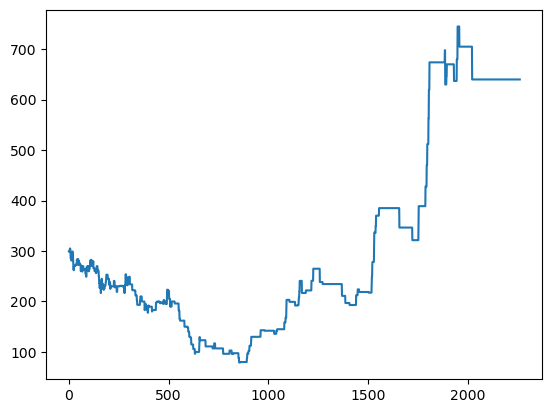

In [2]:
import matplotlib.pyplot as plt

plt.plot(total['close_price'])
plt.show()

In [3]:
total_end_month_df = (
    total
    .sort_values("date")
    .groupby(total["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

total_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45423,TOTAL,2017-01-31,290.01,290.01,93502,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47246,TOTAL,2017-02-28,283.00,283.00,14120,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49362,TOTAL,2017-03-31,269.98,269.98,80734,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51189,TOTAL,2017-04-28,263.00,263.00,13346,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53112,TOTAL,2017-05-31,265.00,265.00,38166,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35375,TOTAL,2026-03-31,640.00,640.00,550791,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281201,TOTAL,2026-04-30,640.00,640.00,17400,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284267,TOTAL,2026-05-29,640.00,640.00,11665,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294195,TOTAL,2026-06-30,640.00,640.00,4582,2026-06-30T15:10:03.08168+00:00,6,2,2026


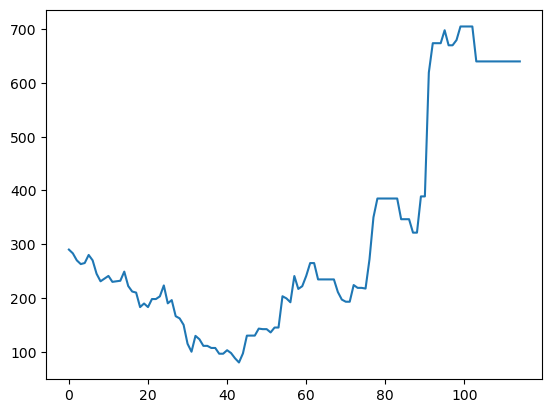

In [4]:
plt.plot(total_end_month_df['close_price'])
plt.show()

In [5]:
total_end_month_df['returns']=total_end_month_df['close_price'].pct_change()*100
total_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45423,TOTAL,2017-01-31,290.01,290.01,93502,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47246,TOTAL,2017-02-28,283.00,283.00,14120,2026-04-08T02:44:45.006295+00:00,2,1,2017,-2.417158
2,49362,TOTAL,2017-03-31,269.98,269.98,80734,2026-04-08T02:45:42.281198+00:00,3,1,2017,-4.600707
3,51189,TOTAL,2017-04-28,263.00,263.00,13346,2026-04-08T02:51:55.619599+00:00,4,2,2017,-2.585377
4,53112,TOTAL,2017-05-31,265.00,265.00,38166,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.760456
...,...,...,...,...,...,...,...,...,...,...,...
110,35375,TOTAL,2026-03-31,640.00,640.00,550791,2026-03-31T15:00:02.085058+00:00,3,1,2026,0.000000
111,281201,TOTAL,2026-04-30,640.00,640.00,17400,2026-04-30T15:00:02.170664+00:00,4,2,2026,0.000000
112,284267,TOTAL,2026-05-29,640.00,640.00,11665,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.000000
113,294195,TOTAL,2026-06-30,640.00,640.00,4582,2026-06-30T15:10:03.08168+00:00,6,2,2026,0.000000


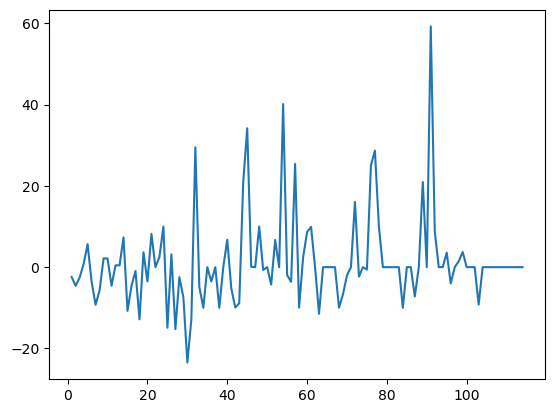

In [6]:
plt.plot(total_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(total_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-9.496243888079727, 3.5426522714728516e-16, 0, 113, {'1%': -3.489589552580676, '5%': -2.887477210140433, '10%': -2.580604145195395}, 778.0737017006526)
stationary


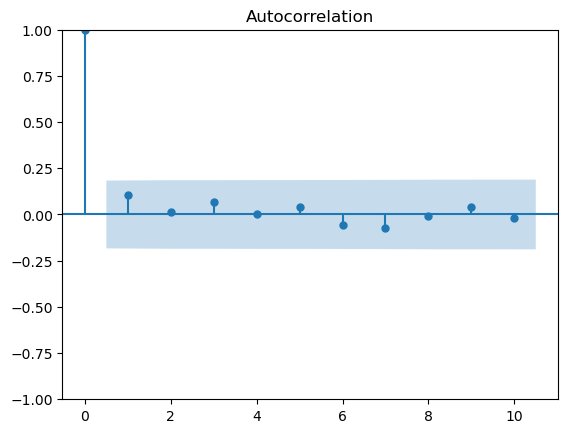

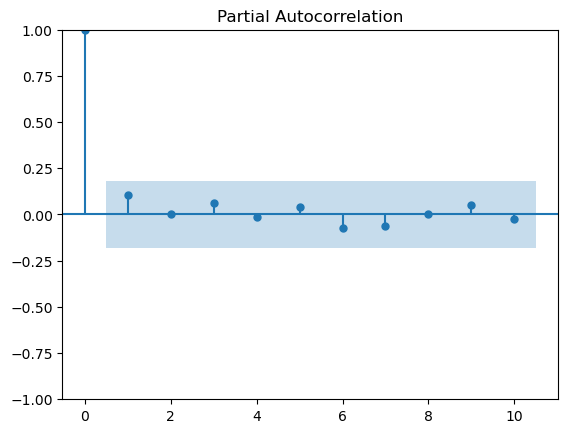

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(total_end_month_df['returns'].dropna(), lags=10)
plot_pacf(total_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=total_end_month_df['close_price'][:-10]
test=total_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, 0.0]
[0, 0, 0, 0, 0, 1, 0.0]
[0, 0, 0, 0, 0, 2, 0.0]
[0, 0, 0, 0, 1, 0, 0.0]
[0, 0, 0, 0, 1, 1, 0.0]
[0, 0, 0, 0, 1, 2, 0.0]
[0, 0, 0, 0, 2, 0, 0.0]
[0, 0, 0, 0, 2, 1, 0.0]
[0, 0, 0, 0, 2, 2, 0.0]
[0, 0, 0, 1, 0, 0, 0.0]
[0, 0, 0, 1, 0, 1, 0.0]
[0, 0, 0, 1, 0, 2, 0.0]
[0, 0, 0, 1, 1, 0, 0.0]
[0, 0, 0, 1, 1, 1, 0.0]
[0, 0, 0, 1, 1, 2, 0.0]
[0, 0, 0, 1, 2, 0, 0.0]
[0, 0, 0, 1, 2, 1, 0.0]
[0, 0, 0, 1, 2, 2, 0.0]
[0, 0, 0, 2, 0, 0, 0.0]
[0, 0, 0, 2, 0, 1, 0.0]
[0, 0, 0, 2, 0, 2, 0.0]
[0, 0, 0, 2, 1, 0, 0.0]
[0, 0, 0, 2, 1, 1, 0.0]
[0, 0, 0, 2, 1, 2, 0.0]
[0, 0, 0, 2, 2, 0, 0.0]
[0, 0, 0, 2, 2, 1, 0.0]
[0, 0, 0, 2, 2, 2, 0.0]
[0, 0, 1, 0, 0, 0, 0.0]
[0, 0, 1, 0, 0, 1, 0.0]
[0, 0, 1, 0, 0, 2, 0.0]
[0, 0, 1, 0, 1, 0, 0.0]
[0, 0, 1, 0, 1, 1, 0.0]
[0, 0, 1, 0, 1, 2, 0.0]
[0, 0, 1, 0, 2, 0, 0.0]
[0, 0, 1, 0, 2, 1, 0.0]
[0, 0, 1, 0, 2, 2, 0.0]
[0, 0, 1, 1, 0, 0, 0.0]
[0, 0, 1, 1, 0, 1, 0.0]
[0, 0, 1, 1, 0, 2, 0.0]
[0, 0, 1, 1, 1, 0, 0.0]
[0, 0, 1, 1, 1, 1, 0.0]
[0, 0, 1, 1, 1, 

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,0.0
480,1,2,2,2,1,0,0.0
481,1,2,2,2,1,1,0.0
482,1,2,2,2,1,2,0.0
483,1,2,2,2,2,0,0.0
...,...,...,...,...,...,...,...
247,1,0,0,0,1,1,0.0
239,0,2,2,2,1,2,0.0
728,2,2,2,2,2,2,0.0
81,0,1,0,0,0,0,1.0


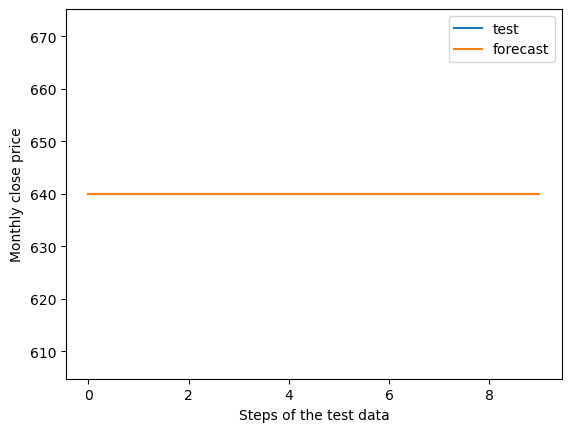

r2_score:  1.0
rmse:  0.0
description:  count    115.000000
mean     309.976000
std      195.870516
min       80.000000
25%      186.350000
50%      234.500000
75%      385.000000
max      705.000000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=total_end_month_df['close_price'][:-10]
y_test=total_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,1,0), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', total_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns. We changed the test size to 20 because the last 10 are constant

In [14]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=total_end_month_df['returns'].dropna()[:-20]
test=total_end_month_df['returns'].dropna()[-20:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=20)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.007807217549044676]
[0, 0, 0, 0, 0, 1, -2.9880336946053965]
[0, 0, 0, 0, 0, 2, -2.831841737262698]
[0, 0, 0, 0, 1, 0, -45.311920797564916]
[0, 0, 0, 0, 1, 1, -11.47814471268497]
[0, 0, 0, 0, 1, 2, -10.459154751510583]
[0, 0, 0, 0, 2, 0, -201.75391221516708]
[0, 0, 0, 0, 2, 1, -60.19633610163316]
[0, 0, 0, 0, 2, 2, -42.22823365889992]
[0, 0, 0, 1, 0, 0, -2.6400783662253144]
[0, 0, 0, 1, 0, 1, -2.8945003805172367]
[0, 0, 0, 1, 0, 2, -3.0177383517987115]
[0, 0, 0, 1, 1, 0, -28.26533906820706]
[0, 0, 0, 1, 1, 1, -10.005528236321256]
[0, 0, 0, 1, 1, 2, -10.295815867885706]
[0, 0, 0, 1, 2, 0, -103.49091694019273]
[0, 0, 0, 1, 2, 1, -47.55094684709537]
[0, 0, 0, 1, 2, 2, -36.32642836101977]
[0, 0, 0, 2, 0, 0, -2.890765876425341]
[0, 0, 0, 2, 0, 1, -3.1425829822675855]
[0, 0, 0, 2, 0, 2, -3.1920860195557017]
[0, 0, 0, 2, 1, 0, -21.43942563599126]
[0, 0, 0, 2, 1, 1, -10.389978815847575]
[0, 0, 0, 2, 1, 2, -9.286999455998853]
[0, 0, 0, 2, 2, 0, -83.7268512836832]
[0, 0, 0, 

In [15]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
177,0,2,0,1,2,0,-23219.032129
186,0,2,0,2,2,0,-14328.532847
663,2,2,0,1,2,0,-12256.940551
654,2,2,0,0,2,0,-9991.866883
672,2,2,0,2,2,0,-8019.988567
...,...,...,...,...,...,...,...
0,0,0,0,0,0,0,-0.007807
324,1,1,0,0,0,0,-0.007807
162,0,2,0,0,0,0,-0.007807
27,0,0,1,0,0,0,-0.007640


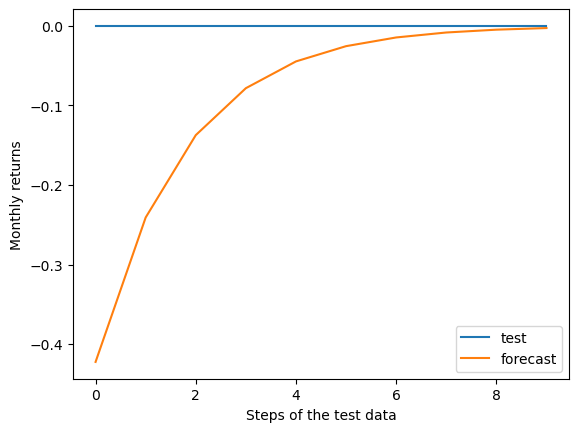

r2_score:  0.0
rmse:  0.16261891888793162
description:  count    114.000000
mean       1.231855
std       11.106286
min      -23.466667
25%       -3.561545
50%        0.000000
75%        1.950923
max       59.244022
Name: returns, dtype: float64


In [16]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=total_end_month_df['returns'].dropna()[:-10]
y_test=total_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,1), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', total_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
